In [1]:
using Jens
using Jens.LensPSF: AbstractPSF, make_kernel, conv_psf,
    GaussianPSF, MoffatPSF, AiryDiskPSF, KernelPSF
using Jens.WFC3: WFC3_UVIS_PSF

using Jens:LensPlots as Jplots

# build-in models

In [ ]:
# create physical psf
gauss  = GaussianPSF(fwhm=0.08)         # 地面 0.08" seeing
moffat = MoffatPSF(fwhm=0.10, alpha=3.0)
airy   = AiryDiskPSF(fwhm=0.08)
wfc3   = WFC3_UVIS_PSF(lambda_eff=606e-9)

WFC3_UVIS_PSF(6.06e-7, 5)

In [15]:
# to matrix
pix_size = 0.029
pix_half = 7
WFC3 = make_kernel(wfc3, pix_size, pix_half);

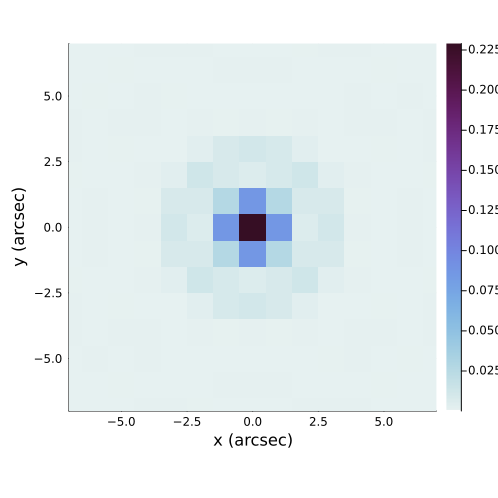

In [16]:
c = Jplots.LensCanvas(;  xlims=(-pix_half,pix_half), ylims=(-pix_half,pix_half),
        size=(500,500))
c = Jplots.PlotPlane!(c, WFC3, colormap=:dense)
display(c)

# external psf

In [27]:
pixel_size = 0.029
your_kernel_matrix = WFC3
your_psf = KernelPSF(your_kernel_matrix, pixel_size)
yourPSF = your_psf.kernel; # matrix

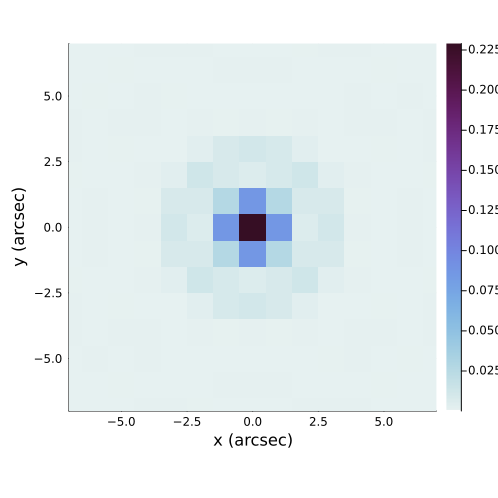

In [28]:
c = Jplots.LensCanvas(;  xlims=(-pix_half,pix_half), ylims=(-pix_half,pix_half),
        size=(500,500))
c = Jplots.PlotPlane!(c, yourPSF, colormap=:dense)
display(c)